In [1]:
# 0.0 量化交易的数学：线性代数

> **为什么我要学这个？**
> 
> 很多量化交易的新手会觉得指标（RSI, MACD）就是全部。但当你开始处理**一篮子股票**（组合管理）或者想理解**市场背后的力量**（因子分析）时，你会发现指标不够用了。
> 
> **线性代数不是为了让你算难题，它是为了让你“批量处理”信息。**

## 学习目标
- 理解向量（Vector）和矩阵（Matrix）在交易中的真实含义
- 掌握矩阵运算在收益率计算和权重调整中的应用
- 直观理解主成分分析（PCA）如何帮我们看清市场

SyntaxError: invalid character '？' (U+FF1F) (3264023557.py, line 3)

## 1. 向量与矩阵：从“单挑”到“群殴”

在只有一只股票时，我们处理的是标量（单个数字）。但现实中我们面对的是整个市场。

### 向量（Vector）是什么？
想象你有一个投资组合，持有了苹果（AAPL）、微软（MSFT）和谷歌（GOOG）。
你可以把它们的权重写成一个**权重向量 $w$**：
$$w = [0.4, 0.3, 0.3]$$
这代表你 40% 的钱买苹果，剩下两家各 30%。

### 矩阵（Matrix）是什么？
矩阵就是把多个向量叠在一起。比如这三只股票过去 5 天的日收益率，就是一个 $5 \times 3$ 的矩阵：

| 日期 | AAPL | MSFT | GOOG |
| :--- | :--- | :--- | :--- |
| Day 1 | 0.01 | -0.01 | 0.02 |
| Day 2 | -0.02 | 0.00 | 0.01 |
| ... | ... | ... | ... |
| Day 5 | -0.01 | 0.04 | 0.05 |

**核心直觉**：矩阵就是一张 Excel 表，它是量化代码处理数据的“基本单位”。

In [2]:
import numpy as np
import pandas as pd

# 用权重向量计算组合收益率
weights = np.array([0.4, 0.3, 0.3]) # 权重向量
returns = np.array([0.01, -0.02, 0.03]) # 三只股票当天的收益率向量

# 组合收益 = 权重1*收益1 + 权重2*收益2 + ...
# 在线性代数里，这就是“点积”（Dot Product）
portfolio_return = np.dot(weights, returns)

print(f"今日组合收益率: {portfolio_return:.4%}")

今日组合收益率: 0.7000%


## 2. 矩阵乘法的奥秘：批量计算收益

如果你有 1000 天的数据和 100 只股票，你想计算这 1000 天组合每天的收益。你不需要写 `for` 循环，只需要一次矩阵乘法。

$$R_{portfolio} = R_{matrix} \times w$$

矩阵乘法的本质是：**重新线性组合**。它把原始的股票收益，按照你的权重重新“揉”成了一个新的时间序列。

### 为什么我们要强调不写循环？
1. **速度**：Python 的 `for` 循环很慢，但 NumPy 的矩阵运算背后是 C 语言优化的，速度快百倍。
2. **清晰**：一行矩阵运算能代替几十行逻辑代码。

In [3]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 模拟 5 天 3 只股票的收益率矩阵数据
np.random.seed(42) # 固定随机数生成器,生成可复现的“随机”数，每次运行代码，生成的"随机"数字序列都完全一样。
# 不产生任何随机数，它只是把 NumPy 内部的一个“隐藏开关”拨到了 42 这个位置。后续所有生成随机数的函数，都会自动去读取这个隐藏开关。
return_matrix = np.random.normal(0.001, 0.02, (5, 3))
# 0.001：设定收益率是 0.1%，意味着你假设这些股票平均每天赚 0.1%。
# 0.02：设定标准差为 2%，意味着每日涨跌幅的典型波动范围是 ±2%。
# 大部分值落在 | 区间     | 概率    | 对应收益率范围           |
#| ------ | ----- | ----------------- |
#| μ ± 1σ | 68.3% | **-1.9% ~ +2.1%** |
#| μ ± 2σ | 95.4% | **-3.9% ~ +4.1%** |
#| μ ± 3σ | 99.7% | **-5.9% ~ +6.1%** |
# 理论上，正态分布取值范围是 (-∞, +∞)，但 99.7% 的数据落在 ±3σ 内。σ西格玛
# 这个矩阵 return_matrix 就是虚拟的"历史行情数据"，可以直接用来测试策略逻辑。
# np.random.seed(42)，让np.random.normal(0.001, 0.02, (5, 3))得结果，每次都一样
print("收益率矩阵 (5天 x 3只股票):")
print(return_matrix)

# 一次性计算 5 天的组合收益
portfolio_returns_5d = np.dot(return_matrix, weights)
print("\n5天组合收益序列:")
print(portfolio_returns_5d)

收益率矩阵 (5天 x 3只股票):
[[ 0.01093428 -0.00176529  0.01395377]
 [ 0.0314606  -0.00368307 -0.00368274]
 [ 0.03258426  0.01634869 -0.00838949]
 [ 0.0118512  -0.00826835 -0.0083146 ]
 [ 0.00583925 -0.0372656  -0.03349836]]

5天组合收益序列:
[ 0.00803026  0.0103745   0.01542146 -0.0002344  -0.01889349]


## 3. 特征值与特征向量：看透市场的“骨架”

想象标普 500 指数里的 500 只股票。它们每天乱跳，看起来有 500 种不同的动向。但实际上，大多数股票是跟着“大盘”走的，或者跟着“科技板块”走的。

**特征分解（Eigen-decomposition）** 就像是给市场照 X 光：
- **特征向量** 代表了市场运动的“方向”（比如：全市场上涨、价值股领先、科技股崩盘）。
- **特征值** 代表了这个方向有多重要（影响力有多大）。

在量化里，我们常说的 **PCA（主成分分析）** 就是利用这个原理，把 500 个混乱的维度压缩成少数几个“核心变量”。

In [2]:
# 这段代码是在做 PCA（主成分分析）降维，目的是把多只股票的收益率数据，压缩成一个能代表它们“共同趋势”的指标。
import matplotlib.pyplot as plt     # 画图用（但这段代码里没用到）
from sklearn.decomposition import PCA   # scikit-learn 机器学习库里的 PCA 降维算法
import yfinance as yf               # 从雅虎财经下载股票数据

# 获取三只高相关科技股的数据
tickers = ['AAPL', 'MSFT', 'GOOGL'] # tickers：选了 苹果、微软、谷歌 三只股票
data = yf.download(tickers, start='2023-01-01', end='2024-01-01', progress=False)['Close']
# 从雅虎下载 2023年1月1日 到 2024年1月1日 的历史数据，不显示下载进度条，保持输出干净，['Close']只取收盘价这一列
rets = data.pct_change().dropna() # pct_change()：把收盘价转成每日涨跌幅（收益率）。
# dropna()：删掉第一行（第一天没有“昨天”，所以是 NaN）。NaN 是 Not a Number 的缩写。

# 使用 PCA 提取第一个主成分（通常代表“市场共同因子”）
# 三只科技股，每天各有一个收益率。它们之间高度相关（科技股经常同涨同跌）。
# PCA 做的事情就是：找一个方向，把三只股票收益率的“共同波动”用一个数表示出来。
# 好比三个人并排走路，他们的位置各有不同，但“整个队伍前进的方向”只需要一个箭头就能描述。
pca = PCA(n_components=1) # 告诉算法：把三维数据压缩成一维
rets_pca = pca.fit_transform(rets) # 先用数据“学习”这个共同方向，然后把数据映射过去


$GOOGL: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-01-01)
$AAPL: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-01-01)
$MSFT: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-01-01)

3 Failed downloads:
['GOOGL', 'AAPL', 'MSFT']: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-01-01)


ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by PCA.

In [6]:
data, data.pct_change(), data.pct_change().dropna(), rets_pca.shape
# data.pct_change()  计算每日涨跌幅（收益率）
# data.pct_change().dropna()删掉含有 NaN 的行  .dropna() 把第一行（全是 NaN 的那行）删掉。
# rets_pca.shape  查看 PCA 降维后数据的形状,.shape就是看一眼数据多大

(Ticker            AAPL       GOOGL        MSFT
 Date                                          
 2023-01-03  122.982719   88.389465  233.452820
 2023-01-04  124.251183   87.357994  223.240860
 2023-01-05  122.933540   85.493408  216.624466
 2023-01-06  127.456779   86.624046  219.177444
 2023-01-09  127.977921   87.298477  221.311432
 ...                ...         ...         ...
 2023-12-22  191.433105  140.330185  368.236603
 2023-12-26  190.889252  140.359940  368.315247
 2023-12-27  190.988129  139.219360  367.735291
 2023-12-28  191.413315  139.080505  368.924805
 2023-12-29  190.375061  138.544937  369.671906
 
 [250 rows x 3 columns],
 Ticker          AAPL     GOOGL      MSFT
 Date                                    
 2023-01-03       NaN       NaN       NaN
 2023-01-04  0.010314 -0.011670 -0.043743
 2023-01-05 -0.010605 -0.021344 -0.029638
 2023-01-06  0.036794  0.013225  0.011785
 2023-01-09  0.004089  0.007786  0.009736
 ...              ...       ...       ...
 2023-12-22 -

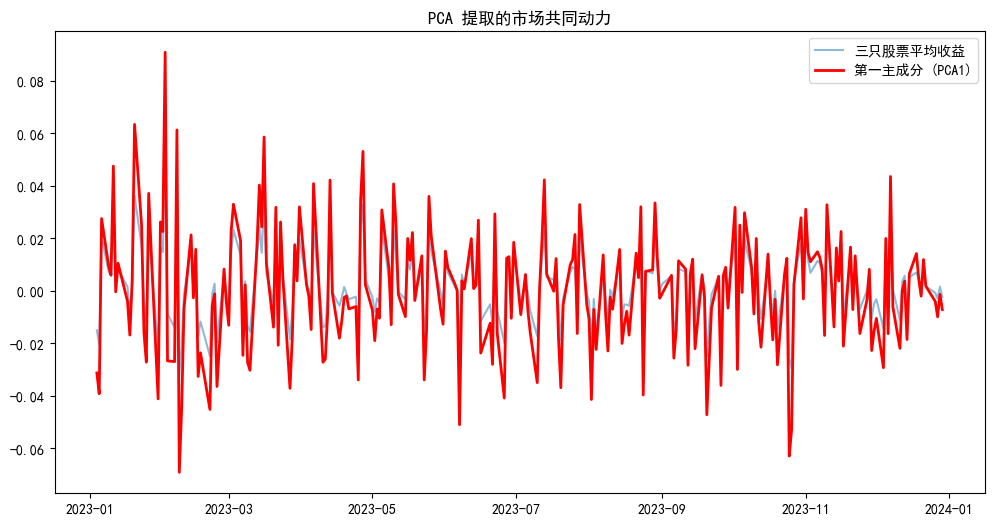

第一主成分解释了这三只股票变动的 70.37%
这说明这三只股票虽然名字不同，但 80% 以上的时间是在跳同一支舞。


In [7]:
plt.figure(figsize=(12, 6)) # 创建一个画布 画布宽 12 英寸，高 6 英寸，是个横向长条，适合看时间序列
plt.plot(rets.index, rets.mean(axis=1), label='三只股票平均收益', alpha=0.5)
# X 轴，日期（rets 的行索引）,Y 轴，每行（每一天）三只股票收益率的算术平均值,透明度 50%，让这条线颜色淡一些，不抢眼
# axis=1 的意思是“沿着列的方向求平均”，也就是把每只股票当成一列，对每一行（每一天）的三列求平均。
plt.plot(rets.index, rets_pca, label='第一主成分 (PCA1)', linewidth=2, color='red')
plt.title("PCA 提取的市场共同动力")
plt.legend() # 自动把前面 label= 标的内容生成一个图例框，方便区分哪条线是哪条。
plt.show()

print(f"第一主成分解释了这三只股票变动的 {pca.explained_variance_ratio_[0]:.2%}")
print("这说明这三只股票虽然名字不同，但 80% 以上的时间是在跳同一支舞。")

## 🎯 练习

1. 创建一个 5×5 的随机收益率矩阵，用矩阵乘法计算等权组合（权重各占 20%）每天的收益率。
2. 使用 `np.linalg.eig()` 手动计算一个 3×3 协方差矩阵的特征值和特征向量，并与 PCA 结果对比。
3. 对标普 500 中的 10 只股票跑 PCA，看第一主成分解释了多少比例的总方差？

---
**下一节** → `01_price_and_return.ipynb`  （我们将把这些数学应用到真实的价格计算中）
